In [ ]:
# Case Study Assignment
# Student Name: YANG Yousen
# Student ID: 5578478

In [ ]:
!pip install pandas requests matplotlib folium

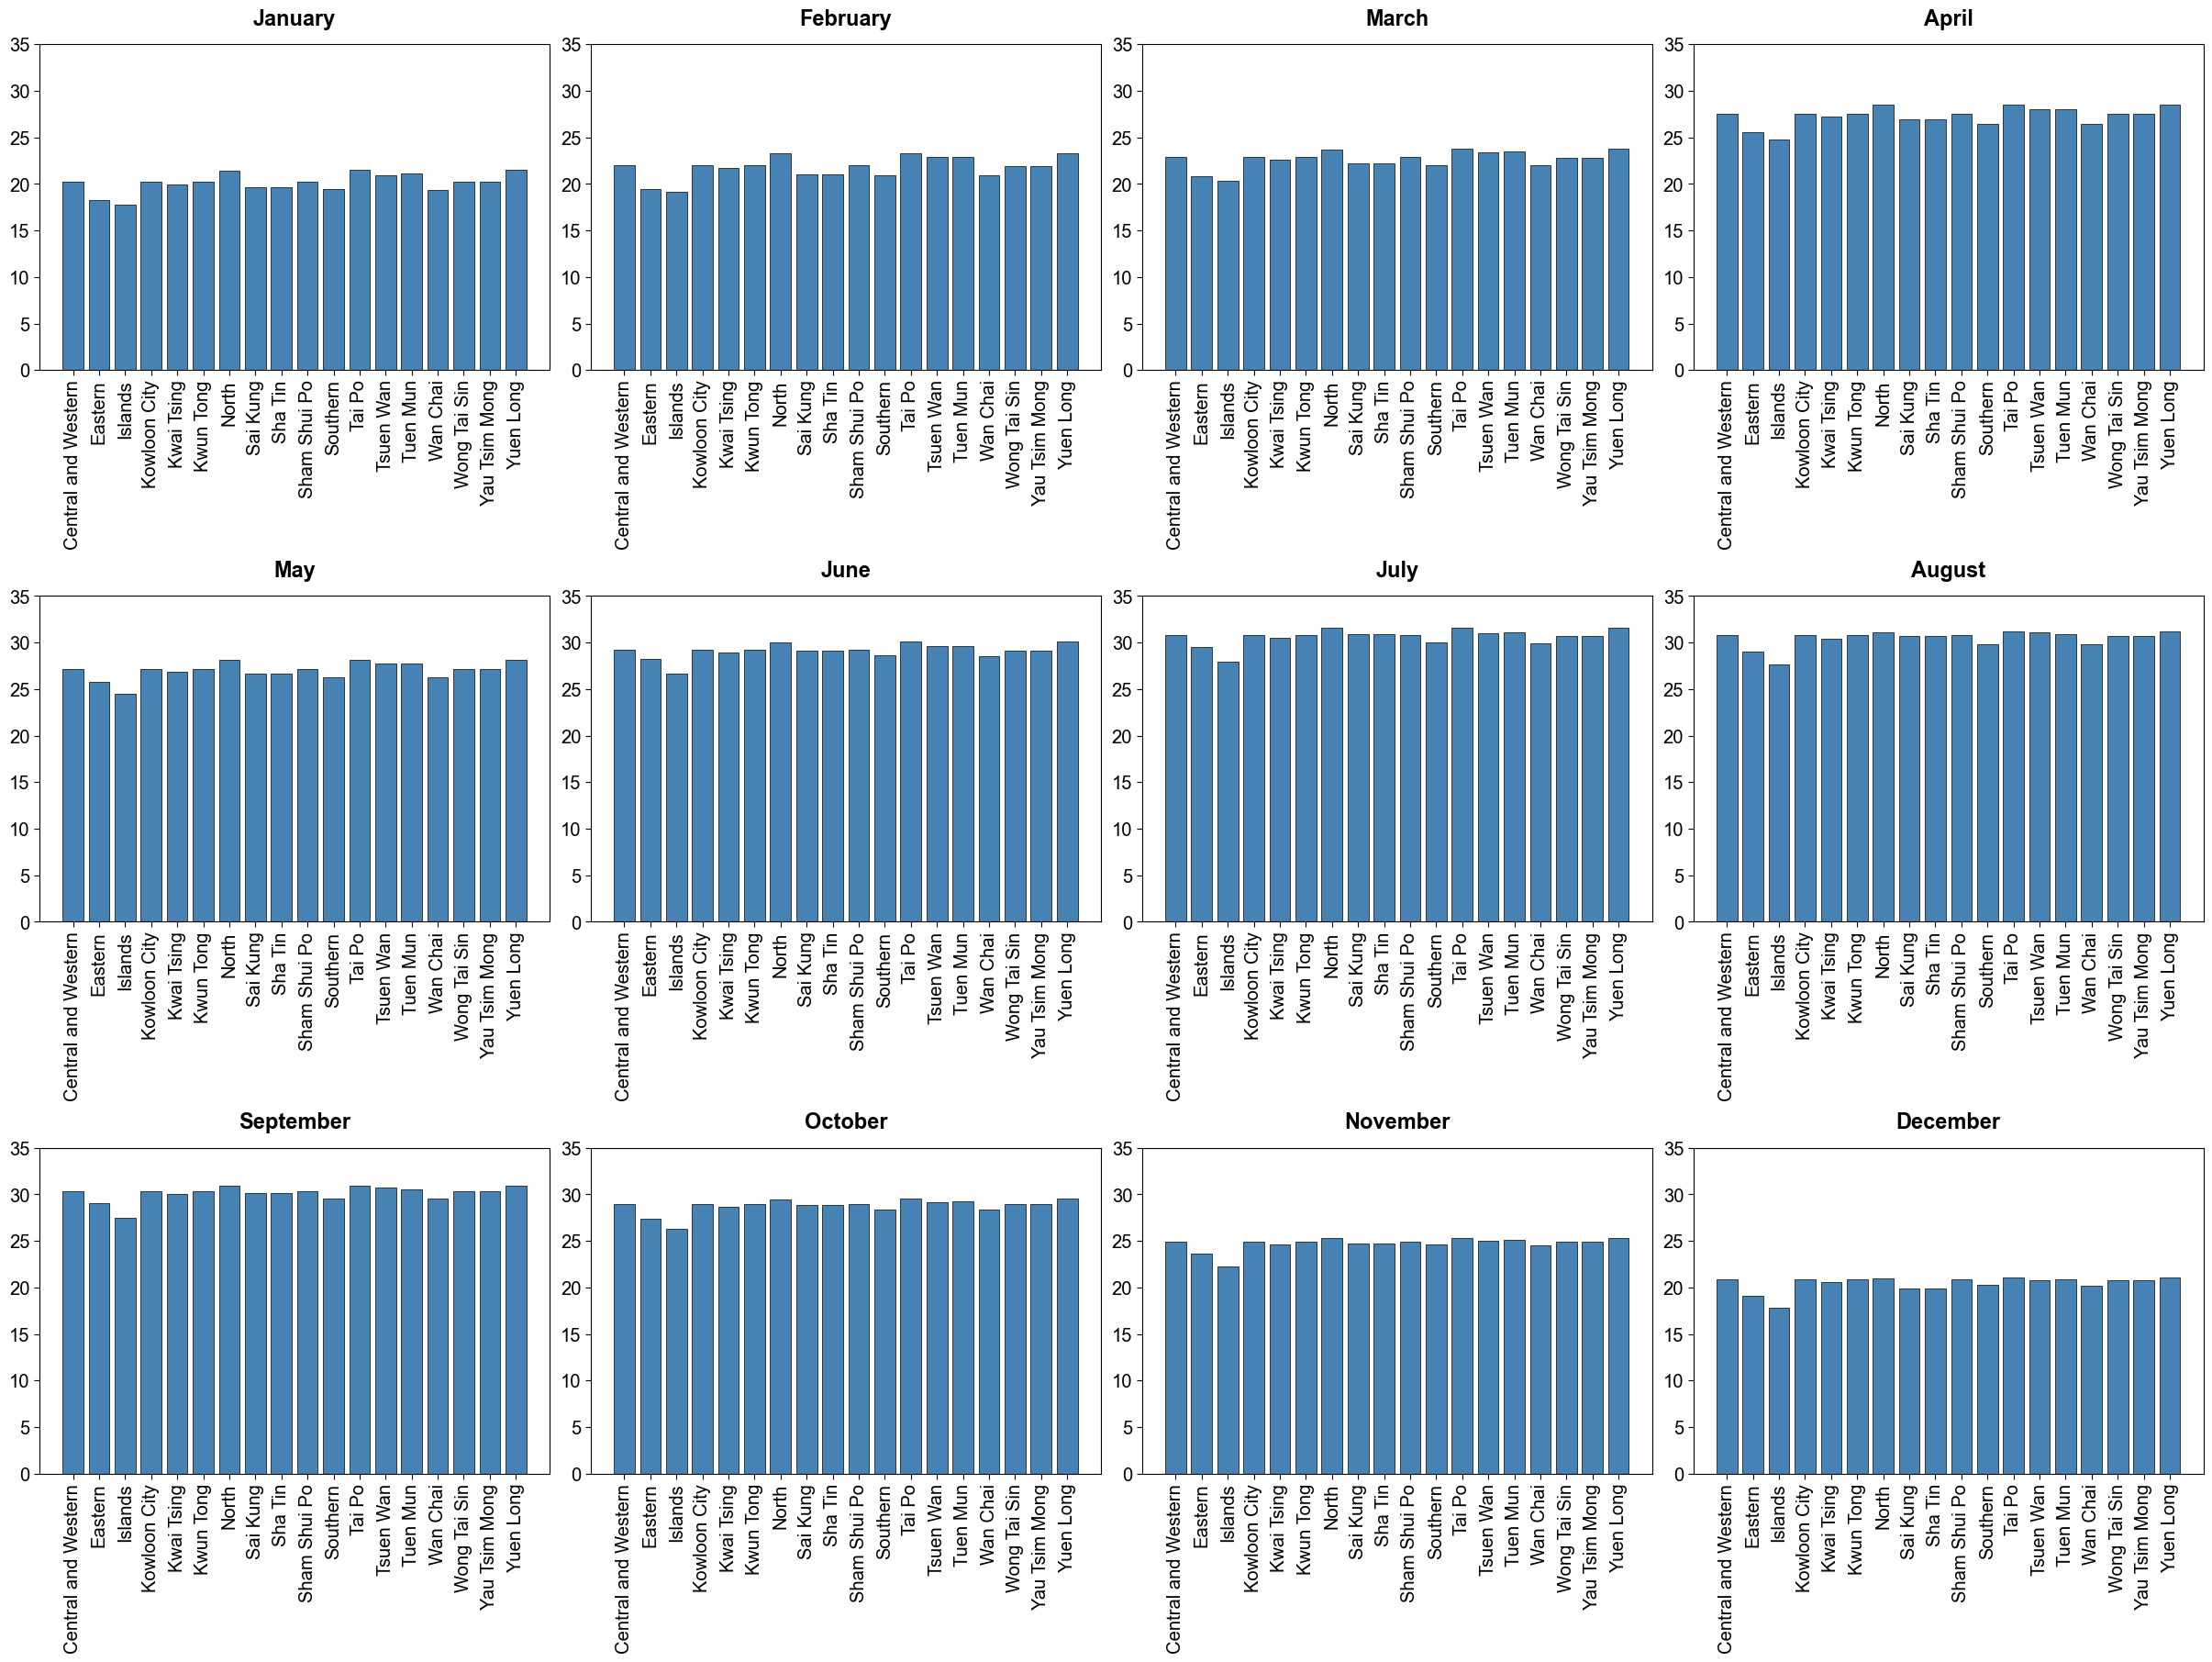

In [1]:
# Phase 1

# 1. Import libraries and configure settings 
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

# Global Configuration (Centralized Management)
plt.rcParams.update({
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.figsize': (24, 18),
    'axes.grid': False,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.bottom': True,
    'axes.spines.left': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out'
})

# Constant Definition (Centralized Management)
DISTRICT_ORDER = [
    "Central and Western", "Eastern", "Islands", "Kowloon City",
    "Kwai Tsing", "Kwun Tong", "North", "Sai Kung",
    "Sha Tin", "Sham Shui Po", "Southern", "Tai Po",
    "Tsuen Wan", "Tuen Mun", "Wan Chai", "Wong Tai Sin",
    "Yau Tsim Mong", "Yuen Long"
]

MONTH_NAMES = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

API_CONFIG = {
    "base_url": "https://archive-api.open-meteo.com/v1/archive",
    "params": {
        "start_date": "2024-01-01",
        "end_date": "2024-12-31",
        "daily": "temperature_2m_max",
        "timezone": "GMT",
        "units": "metric"
    }
}

PLOT_CONFIG = {
    "bar_color": "steelblue",
    "bar_alpha": 1,
    "bar_edge_color": "black",
    "bar_linewidth": 0.5,
    "title_fontsize": 17,
    "xtick_fontsize": 14.5,
    "ytick_fontsize": 14.5,
    "y_lim": (0, 35),
    "y_ticks": range(0, 36, 5),
    "spine_color": "black",
    "tick_color": "black"
}

# 2. Core Functions 
def load_district_data(file_path="district.csv"):
    """Load and validate regional coordinate data"""
    try:
        districts = pd.read_csv(file_path)
        districts['name'] = districts['name'].str.strip('"')
        
        # Validate regional integrity
        missing_districts = set(DISTRICT_ORDER) - set(districts['name'])
        extra_districts = set(districts['name']) - set(DISTRICT_ORDER)
        
        if missing_districts:
            print(f"Warning: Missing districts in CSV: {', '.join(missing_districts)}")
        if extra_districts:
            print(f"Warning: Extra districts in CSV: {', '.join(extra_districts)}")
            
        return districts
    except FileNotFoundError:
        raise FileNotFoundError("Please place 'district.csv' in the same directory!")

def fetch_monthly_temperature(latitude, longitude):
    """Obtain the monthly average maximum temperature of a single region"""
    params = API_CONFIG["params"].copy()
    params.update({"latitude": latitude, "longitude": longitude})
    
    try:
        response = requests.get(API_CONFIG["base_url"], params=params)
        response.raise_for_status()
        data = response.json()
        
        # Process data and calculate the monthly average
        df = pd.DataFrame({
            "date": pd.to_datetime(data['daily']['time']),
            "temp": data['daily']['temperature_2m_max']
        })
        return df.groupby(df['date'].dt.month)['temp'].mean()
    except Exception as e:
        print(f"Data fetch failed: {str(e)}")
        return pd.Series([0]*12, index=range(1,13))

def create_temperature_plot(temps_df):
    """Create a temperature visualization chart"""
    plt.close('all')
    fig, axes = plt.subplots(3, 4, constrained_layout=True)
    axes = axes.flatten()
    
    # Iterate through each month to plot the chart
    for idx, month_name in enumerate(MONTH_NAMES):
        ax = axes[idx]
        month_num = idx + 1
        
        # Obtain the current month's data
        data = temps_df.loc[month_num] if month_num in temps_df.index else pd.Series([0]*len(DISTRICT_ORDER), index=DISTRICT_ORDER)
        
        # Plot a bar chart
        ax.bar(
            range(len(data)),
            data.values,
            color=PLOT_CONFIG["bar_color"],
            alpha=PLOT_CONFIG["bar_alpha"],
            edgecolor=PLOT_CONFIG["bar_edge_color"],
            linewidth=PLOT_CONFIG["bar_linewidth"]
        )
        
        # Chart Style Configuration
        ax.set_title(month_name, fontsize=PLOT_CONFIG["title_fontsize"], fontweight='bold', pad=15, color='black')
        ax.set_ylim(PLOT_CONFIG["y_lim"])
        ax.set_yticks(PLOT_CONFIG["y_ticks"])
        
        # X-axis Configuration
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(
            data.index,
            rotation=90,
            ha='center',
            va='top',
            fontsize=PLOT_CONFIG["xtick_fontsize"],  
            color='black'
        )
        
        # Tick and Border Style
        for spine in ax.spines.values():
            spine.set_color(PLOT_CONFIG["spine_color"])
        
        ax.tick_params(
            axis='both',
            which='major',
            length=4,
            width=0.8,
            color=PLOT_CONFIG["tick_color"],
            labelsize=PLOT_CONFIG["ytick_fontsize"],
            labelcolor='black'
        )
    
    plt.show()

# 3. Main Execution Flow 
if __name__ == "__main__":
    # Load regional data
    districts_df = load_district_data()
    
    # Obtain temperature data in batches
    monthly_temps = {}
    for _, row in districts_df.iterrows():
        monthly_temps[row['name']] = fetch_monthly_temperature(row['latitude'], row['longitude'])
    
    # Organize data and plot charts
    temps_df = pd.DataFrame(monthly_temps).reindex(columns=DISTRICT_ORDER)
    create_temperature_plot(temps_df)

In [4]:
# Phase 2

import pandas as pd
import requests
import folium
from folium import IFrame, Popup
import os
import re
from IPython.display import display

# -------------------------- Configuration Parameters --------------------------
class Config:
    # Map basic configuration
    MAP_LOCATION = [22.3020, 114.1743]
    MAP_TILES = 'openstreetmap'
    MAP_ZOOM = 12
    MAP_SAVE_PATH = "HK_temp_aqhi_map.html"
    
    # Data file paths
    DISTRICT_CSV = "district.csv"
    STATION_CSV = "station.csv"
    AQHI_FOLDER = "aqi"  
    
    # Weather API configuration
    OPEN_METEO_API = "https://archive-api.open-meteo.com/v1/archive"
    TEMP_PARAMS = {
        "start_date": "2024-01-01",
        "end_date": "2024-12-31",
        "daily": "temperature_2m_max",
        "timezone": "GMT",
        "units": "metric"
    }
    
    # Air Quality Health Index monitoring stations
    AQHI_STATIONS = [
        "Central/Western", "Southern", "Eastern", "Kwun Tong",
        "Sham Shui Po", "Kwai Chung", "Tsuen Wan", "Tseung Kwan O",
        "Yuen Long", "Tuen Mun", "Tung Chung", "Tai Po",
        "Sha Tin", "North", "Tap Mun", "Causeway Bay",
        "Central", "Mong Kok"
    ]


# -------------------------- Data Processing Functions --------------------------
def load_district_data(file_path=Config.DISTRICT_CSV):
    """Load district coordinate data"""
    try:
        districts = pd.read_csv(file_path)
        districts['name'] = districts['name'].str.strip('"')
        return districts
    except FileNotFoundError:
        raise FileNotFoundError(f"District file not found: {file_path}")


def load_station_data(file_path=Config.STATION_CSV):
    """Load monitoring station coordinate data"""
    try:
        stations = pd.read_csv(file_path)
        stations['name'] = stations['name'].str.strip('"')
        missing = set(Config.AQHI_STATIONS) - set(stations['name'])
        if missing:
            print(f"Warning: Missing monitoring stations: {', '.join(missing)}")
        return stations
    except FileNotFoundError:
        raise FileNotFoundError(f"Station file not found: {file_path}")


def fetch_annual_temp_avg(latitude, longitude):
    """Fetch annual average maximum temperature for specified coordinates"""
    params = Config.TEMP_PARAMS.copy()
    params.update({"latitude": latitude, "longitude": longitude})
    try:
        response = requests.get(Config.OPEN_METEO_API, params=params)
        response.raise_for_status()
        data = response.json()
        temp_df = pd.DataFrame({
            "date": pd.to_datetime(data['daily']['time']),
            "day_max_temp": data['daily']['temperature_2m_max']
        })
        return round(temp_df['day_max_temp'].mean(), 2)
    except Exception as e:
        print(f"Failed to fetch temperature data: {e}")
        return 0.0


def clean_aqi_value(value):
    """Clean AQHI value"""
    if pd.isna(value) or str(value).strip() in ["", "NA"]:
        return 0.0  # Fill missing values with 0
    cleaned = re.sub(r'[^0-9.]', '', str(value))  # Remove symbols like +, *
    return float(cleaned) if cleaned else 0.0


def calculate_annual_aqhi_avg():
    aqhi_daily_records = {station: [] for station in Config.AQHI_STATIONS}
    
    try:
        csv_files = [
            f for f in os.listdir(Config.AQHI_FOLDER)
            if f.startswith("2024") and f.endswith("_Eng.csv")
        ]
        if not csv_files:
            raise FileNotFoundError("No 2024 AQHI CSV files found (naming format: 2024xx_Eng.csv)")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return {station: 0.0 for station in Config.AQHI_STATIONS}
    
    for file in csv_files:
        file_path = os.path.join(Config.AQHI_FOLDER, file)
        try:
            df = pd.read_csv(file_path)
            # Column name processing: only remove leading/trailing spaces
            df.columns = [col.strip() for col in df.columns] 
            
            daily_max_rows = df[df.iloc[:, 1].str.strip() == "Daily Max"]
            
            if daily_max_rows.empty:
                print(f"Warning: 'Daily Max' row not found in file {file}, skipping this file")
                continue
            
            for _, row in daily_max_rows.iterrows():
                for station in Config.AQHI_STATIONS:
                    # Fuzzy match column name
                    matched_col = next(
                        (col for col in df.columns if station.split("/")[0] in col),
                        None
                    )
                    if matched_col:
                        cleaned_val = clean_aqi_value(row[matched_col])
                        aqhi_daily_records[station].append(cleaned_val)
                    else:
                        aqhi_daily_records[station].append(0.0)
                        print(f"Warning: Column for station {station} missing in file {file}, filling with 0.0")
        
        except Exception as e:
            print(f"Error processing file {file}: {e}")
            continue
    
    aqhi_annual_avg = {}
    for station, daily_values in aqhi_daily_records.items():
        if daily_values:
            avg = round(sum(daily_values) / len(daily_values), 2)
        else:
            avg = 0.0
            print(f"Warning: No valid data for station {station}, average set to 0.0")
        aqhi_annual_avg[station] = avg
    
    return aqhi_annual_avg


# -------------------------- Map Generation Function --------------------------
def create_hk_map():
    HK_map = folium.Map(
        location=Config.MAP_LOCATION,
        tiles=Config.MAP_TILES,
        zoom_start=Config.MAP_ZOOM
    )
    fg_temp = folium.FeatureGroup(name='Temperature').add_to(HK_map)
    fg_aqhi = folium.FeatureGroup(name='AQHI').add_to(HK_map)
    
    districts = load_district_data()
    stations = load_station_data()
    aqhi_data = calculate_annual_aqhi_avg()  
    
    # Add blue temperature markers
    for _, row in districts.iterrows():
        temp_avg = fetch_annual_temp_avg(row['latitude'], row['longitude'])
        html = f"""
        <p><b>{row['name']}</b></p>
        <p>Annual Average Temperature: {temp_avg}°C</p>
        """
        iframe = IFrame(html=html, width=300, height=100)
        popup = Popup(iframe, max_width=2650)
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            icon=folium.Icon(color="blue"),
            popup=popup
        ).add_to(fg_temp)
    
    # Add red AQHI markers
    for _, row in stations.iterrows():
        if row['name'] in aqhi_data:
            aqhi_avg = aqhi_data[row['name']]
            html = f"""
            <p><b>{row['name']}</b></p>
            <p>Annual Average AQHI: {aqhi_avg}</p>
            """
            iframe = IFrame(html=html, width=300, height=100)
            popup = Popup(iframe, max_width=2650)
            folium.Marker(
                location=[row['latitude'], row['longitude']],
                icon=folium.Icon(color="red"),
                popup=popup
            ).add_to(fg_aqhi)
    
    folium.LayerControl().add_to(HK_map)
    HK_map.save(Config.MAP_SAVE_PATH)
    print(f"Map saved to: {Config.MAP_SAVE_PATH}")
    return HK_map


# -------------------------- Main Program --------------------------
if __name__ == "__main__":
    final_map = create_hk_map()
    try:
        display(final_map)
    except NameError:
        print("Run in Jupyter environment to display the map directly")

Map saved to: HK_temp_aqhi_map.html
